# Data-to-Data Flow Matching Experiments

## Motivation / Overview

Previous experiments investigated whether a pretrained noise-to-data Rectified Flow model can be directly applied for data-to-data interpolation. Since the original model was trained only to transport Gaussian noise towards the data distribution, applying it to existing samples did not result in meaningful transformations.

Therefore, a new data-to-data Flow Matching model is trained. Instead of learning a noise-to-data transport, the model learns a conditional transport between two visually similar but semantically different data distributions.

The goal is not to recover a unique transformation between individual samples, but to investigate whether the learned flow produces meaningful intermediate states and structured transition trajectories between distributions.

## Objective

n this experiment, a Rectified Flow model is trained using a data-to-data Flow Matching objective.

Instead of transporting Gaussian noise to the data distribution, the model learns a conditional transport field between samples drawn from two different data distributions:

$$
x_0 \sim \mathcal{N}(0,I), \quad x_1 \sim p_{data}
$$

During training, source and target samples are paired randomly within predefined class mappings. Consequently, the objective is not to learn a unique transformation between individual images, but to model transitions between distributions.

$$
x_A \sim p_A, \quad x_B \sim p_B
$$

The interpolation path is defined as:

$$
z_t=(1-t)x_A+t x_B
$$

where:

- $t=0$ corresponds to the source sample,
- $t=1$ corresponds to the target sample.

The target velocity is given by:

$$
u_t=x_B-x_A
$$

The model learns to approximate this velocity field:

$$
v_\theta(z_t,t)\approx x_B-x_A
$$

The goal of this experiment is to investigate:

- whether the learned flow produces meaningful transitions between source and target distributions,
- whether intermediate states exhibit coherent semantic evolution,
- whether trajectories remain close to the empirical data manifold,
and
- how learned trajectories compare to simple linear interpolation.

In [2]:
import os
import random
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

# Keep runs reproducible for easier comparison between experiments.
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

# Use GPU when available, otherwise run on CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# Detect Colab runtime.
IN_COLAB = "google.colab" in sys.modules


def find_repo_root():
    """Locate minRF_interpolation repo in local VS Code or Colab environments."""
    candidates = []

    # 1) Explicit override if user sets it.
    env_repo = os.environ.get("MINRF_REPO")
    if env_repo:
        candidates.append(Path(env_repo).expanduser())

    # 2) Common direct locations.
    cwd = Path.cwd().resolve()
    candidates.extend(
        [
            cwd,
            cwd / "minRF_interpolation",
            cwd.parent / "minRF_interpolation",
            Path("/content/minRF_interpolation"),
            Path("/content/drive/MyDrive/minRF_interpolation"),
            Path("/content/Projects/minRF_interpolation"),
            Path.home() / "Projects" / "minRF_interpolation",
            Path("/home/felicitasl/Projects/minRF_interpolation"),
        ]
    )

    # 3) Walk upwards and check each parent for repo folder.
    for parent in [cwd, *cwd.parents]:
        candidates.append(parent / "minRF_interpolation")

    seen = set()
    for path in candidates:
        p = path.expanduser().resolve()
        if str(p) in seen:
            continue
        seen.add(str(p))
        if (p / "dit.py").exists():
            return p

    return None


repo_path = find_repo_root()

# Colab fallback: clone repo automatically if not found.
if repo_path is None and IN_COLAB:
    repo_url = os.environ.get("MINRF_REPO_URL", "https://github.com/Felinchen76/minRF_interpolation.git")
    clone_target = Path("/content/minRF_interpolation")

    if not clone_target.exists():
        print("Repository not found locally. Cloning:", repo_url)
        subprocess.run(["git", "clone", repo_url, str(clone_target)], check=True)

    repo_path = find_repo_root()

if repo_path is None:
    raise FileNotFoundError(
        "Could not locate minRF_interpolation repository. "
        "Set environment variable MINRF_REPO, or in Colab set MINRF_REPO_URL and rerun this cell. "
        "Checked cwd=" + str(Path.cwd().resolve())
    )

print("Using repo_path:", repo_path)

if str(repo_path) not in sys.path:
    sys.path.insert(0, str(repo_path))

from dit import DiT_Llama

Using device: cuda
Repository not found locally. Cloning: https://github.com/Felinchen76/minRF_interpolation.git
Using repo_path: /content/minRF_interpolation


## 1. Lightweight Data-to-Data Dataset (MNIST)

For a first controlled setup, we use MNIST and build **paired samples**:

- source sample: $x_A$ with label $y_A$
- target sample: $x_B$ with label $y_B$

To keep the task meaningful and not too difficult, we train on a small set of class mappings:

- $0 \rightarrow 1$
- $1 \rightarrow 7$
- $2 \rightarrow 3$
- $3 \rightarrow 8$
- $4 \rightarrow 9$
- $5 \rightarrow 6$

This gives a simple but non-trivial data-to-data transport task.

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Pad(2),
    transforms.Normalize((0.5,), (0.5,)),
])

train_dataset = datasets.MNIST(
    root=str(repo_path / "data"),
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root=str(repo_path / "data"),
    train=False,
    download=True,
    transform=transform,
)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

# Restrict to a small, explicit set of class transitions.
TRAIN_CLASS_PAIRS = [(0, 1), (1, 7), (2, 3), (3, 8), (4, 9), (5, 6)]


def build_label_index(ds):
    label_to_indices = {i: [] for i in range(10)}
    for idx, (_, y) in enumerate(ds):
        label_to_indices[int(y)].append(idx)
    return label_to_indices


train_label_index = build_label_index(train_dataset)
test_label_index = build_label_index(test_dataset)


class PairMNISTDataset(Dataset):
    """Creates (x_A, x_B, cond_id, y_A, y_B) for selected class mappings."""

    def __init__(self, ds, label_index, class_pairs, n_pairs=60000):
        self.ds = ds
        self.label_index = label_index
        self.class_pairs = class_pairs
        self.n_pairs = n_pairs

    def __len__(self):
        return self.n_pairs

    def __getitem__(self, idx):
        # Randomly choose one mapping pair per item.
        y_a, y_b = random.choice(self.class_pairs)

        idx_a = random.choice(self.label_index[y_a])
        idx_b = random.choice(self.label_index[y_b])

        x_a, _ = self.ds[idx_a]
        x_b, _ = self.ds[idx_b]

        # Encode source-target class pair as a single condition in [0, 99].
        cond_id = y_a * 10 + y_b

        return x_a, x_b, cond_id, y_a, y_b


train_pairs = PairMNISTDataset(
    ds=train_dataset,
    label_index=train_label_index,
    class_pairs=TRAIN_CLASS_PAIRS,
    n_pairs=50000,
)

test_pairs = PairMNISTDataset(
    ds=test_dataset,
    label_index=test_label_index,
    class_pairs=TRAIN_CLASS_PAIRS,
    n_pairs=5000,
)

train_loader = DataLoader(train_pairs, batch_size=128, shuffle=True, drop_last=True)
test_loader = DataLoader(test_pairs, batch_size=128, shuffle=False, drop_last=False)

print("Train pair batches:", len(train_loader))
print("Test pair batches:", len(test_loader))

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 488kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.69MB/s]


Train size: 60000
Test size: 10000
Train pair batches: 390
Test pair batches: 40


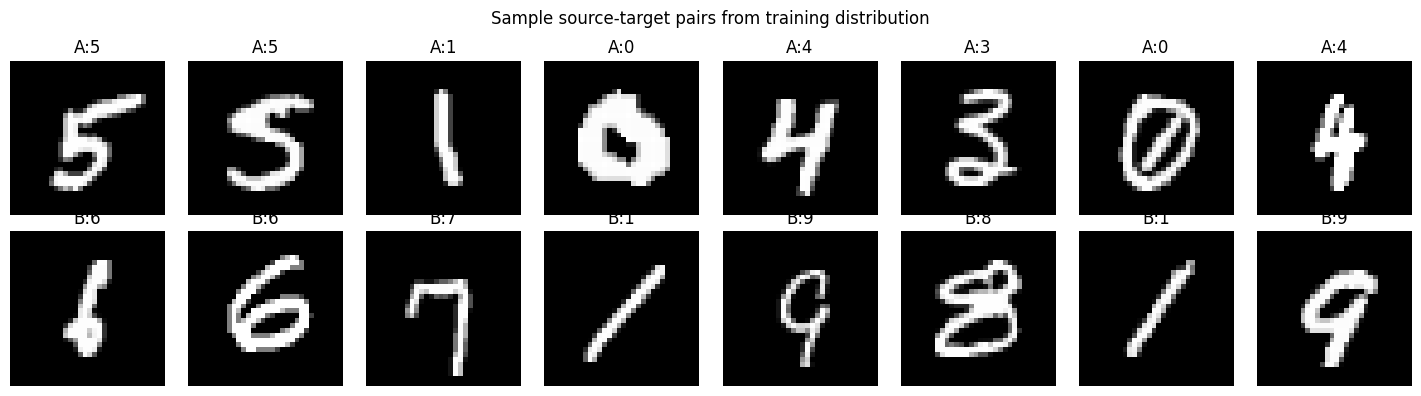

In [4]:
def denorm(x):
    return (x * 0.5 + 0.5).clamp(0, 1)


def show_pair_examples(pair_loader, n=8):
    x_a, x_b, _, y_a, y_b = next(iter(pair_loader))

    fig, axes = plt.subplots(2, n, figsize=(1.8 * n, 4))
    for i in range(n):
        axes[0, i].imshow(denorm(x_a[i]).squeeze(), cmap="gray")
        axes[0, i].set_title(f"A:{int(y_a[i])}")
        axes[0, i].axis("off")

        axes[1, i].imshow(denorm(x_b[i]).squeeze(), cmap="gray")
        axes[1, i].set_title(f"B:{int(y_b[i])}")
        axes[1, i].axis("off")

    axes[0, 0].set_ylabel("Source", fontsize=11)
    axes[1, 0].set_ylabel("Target", fontsize=11)
    plt.suptitle("Sample source-target pairs from training distribution")
    plt.tight_layout()
    plt.show()


show_pair_examples(train_loader, n=8)

## 2. Data-to-Data Rectified Flow (rf.py-style)

We keep the same core idea as in `rf.py`, but replace the training objective:

- sample source/target pair $(x_A, x_B)$
- sample time $t \in [0,1]$
- construct point on path $z_t = (1-t)x_A + t x_B$
- train model to predict velocity $u_t = x_B - x_A$

So the model learns a transport field between data samples rather than from noise to data.

In [5]:
class DataToDataRF:
    def __init__(self, model):
        self.model = model

    def forward(self, x_a, x_b, cond):
        b = x_a.size(0)

        t = torch.rand((b,), device=x_a.device)
        texp = t.view([b, *([1] * len(x_a.shape[1:]))])

        z_t = (1 - texp) * x_a + texp * x_b
        target_velocity = x_b - x_a

        pred_velocity = self.model(z_t, t, cond)
        loss = F.mse_loss(pred_velocity, target_velocity)

        return loss

    @torch.no_grad()
    def sample(self, x_start, cond, steps=50):
        """Integrate the learned vector field from t=0 to t=1."""
        b = x_start.size(0)
        dt = 1.0 / steps
        dt_tensor = torch.tensor([dt] * b, device=x_start.device).view(
            [b, *([1] * len(x_start.shape[1:]))]
        )

        z = x_start.clone()
        trajectory = [z.clone()]

        # Forward integration: z <- z + dt * v_theta(z_t, t)
        for i in range(steps):
            t = torch.tensor([(i / steps)] * b, device=x_start.device)
            velocity = self.model(z, t, cond)
            z = z + dt_tensor * velocity
            trajectory.append(z.clone())

        return trajectory

In [10]:
# Small DiT config to keep notebook training manageable.
channels = 1
model = DiT_Llama(
    channels,
    32,
    dim=64,
    n_layers=4,
    n_heads=4,
    num_classes=100,  # encoded pair condition: source_label*10 + target_label
).to(device)

rf_d2d = DataToDataRF(model)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)

model_size = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {model_size:,}")

# Training behavior:
# - If checkpoint exists and FORCE_RETRAIN=False, model is loaded and training is skipped.
# - Set FORCE_RETRAIN=True to run a fresh training.
FORCE_RETRAIN = False

# Match the original rf.py spirit by default.
TRAINING_PROFILE = "full"  # "full" (100 epochs) or "quick" (8 epochs)
if TRAINING_PROFILE == "full":
    EPOCHS = 100
    MAX_BATCHES_PER_EPOCH = None  # None = use full dataloader each epoch
    EVAL_BATCHES_PER_EPOCH = None  # None = full test loader each epoch
elif TRAINING_PROFILE == "quick":
    EPOCHS = 8
    MAX_BATCHES_PER_EPOCH = 250
    EVAL_BATCHES_PER_EPOCH = 20
else:
    raise ValueError("TRAINING_PROFILE must be 'full' or 'quick'.")

# Early stopping on test loss.
USE_EARLY_STOPPING = True
EARLY_STOPPING_PATIENCE = 10
EARLY_STOPPING_MIN_DELTA = 1e-4

# Checkpoint strategy.
run_dir = repo_path / "assets" / "d2d_runs"
run_dir.mkdir(parents=True, exist_ok=True)
latest_ckpt_path = run_dir / "d2d_checkpoint_latest.pt"
best_ckpt_path = run_dir / "d2d_checkpoint_best.pt"
LOAD_BEST_IF_AVAILABLE = True


def eval_epoch_loss(model_rf, loader, device, max_batches=None):
    model_rf.model.eval()
    total = 0.0
    count = 0

    with torch.no_grad():
        for i, (x_a, x_b, cond, _, _) in enumerate(loader):
            if max_batches is not None and i >= max_batches:
                break

            x_a = x_a.to(device)
            x_b = x_b.to(device)
            cond = cond.to(device)

            b = x_a.size(0)
            t = torch.rand((b,), device=device)
            texp = t.view([b, *([1] * len(x_a.shape[1:]))])
            z_t = (1 - texp) * x_a + texp * x_b
            target_velocity = x_b - x_a

            pred_velocity = model_rf.model(z_t, t, cond)
            loss = F.mse_loss(pred_velocity, target_velocity)

            total += loss.item()
            count += 1

    return total / max(1, count)


loss_history = []
train_loss_history = []
val_loss_history = []
trained_this_session = False

load_path = None
if LOAD_BEST_IF_AVAILABLE and best_ckpt_path.exists():
    load_path = best_ckpt_path
elif latest_ckpt_path.exists():
    load_path = latest_ckpt_path

if load_path is not None and not FORCE_RETRAIN:
    payload = torch.load(load_path, map_location=device)

    # Backward compatibility: allow loading old plain state_dict checkpoints.
    if isinstance(payload, dict) and "model_state_dict" in payload:
        rf_d2d.model.load_state_dict(payload["model_state_dict"])
        if "optimizer_state_dict" in payload:
            optimizer.load_state_dict(payload["optimizer_state_dict"])
        loss_history = payload.get("loss_history", [])
        train_loss_history = payload.get("train_loss_history", loss_history)
        val_loss_history = payload.get("val_loss_history", [])
        print("Loaded checkpoint payload from:", load_path)
    else:
        rf_d2d.model.load_state_dict(payload)
        print("Loaded legacy state_dict checkpoint from:", load_path)

else:
    trained_this_session = True

    best_val_loss = float("inf")
    best_epoch = -1
    epochs_no_improve = 0

    for epoch in range(EPOCHS):
        rf_d2d.model.train()
        running = 0.0

        if MAX_BATCHES_PER_EPOCH is None:
            steps_limit = len(train_loader)
        else:
            steps_limit = min(MAX_BATCHES_PER_EPOCH, len(train_loader))

        for step, (x_a, x_b, cond, _, _) in enumerate(train_loader):
            if step >= steps_limit:
                break

            x_a = x_a.to(device)
            x_b = x_b.to(device)
            cond = cond.to(device)

            optimizer.zero_grad()
            loss = rf_d2d.forward(x_a, x_b, cond)
            loss.backward()
            optimizer.step()

            running += loss.item()

        train_epoch_loss = running / max(1, steps_limit)
        val_epoch_loss = eval_epoch_loss(
            rf_d2d,
            test_loader,
            device,
            max_batches=EVAL_BATCHES_PER_EPOCH,
        )

        train_loss_history.append(train_epoch_loss)
        val_loss_history.append(val_epoch_loss)
        loss_history.append(train_epoch_loss)

        print(
            f"Epoch {epoch + 1:03d}/{EPOCHS} "
            f"| train: {train_epoch_loss:.5f} "
            f"| val: {val_epoch_loss:.5f}"
        )

        # Save latest every epoch so interrupted runs can be resumed safely.
        latest_payload = {
            "model_state_dict": rf_d2d.model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "loss_history": loss_history,
            "train_loss_history": train_loss_history,
            "val_loss_history": val_loss_history,
            "best_val_loss": best_val_loss,
            "best_epoch": best_epoch,
            "config": {
                "channels": channels,
                "img_size": 32,
                "dim": 64,
                "n_layers": 4,
                "n_heads": 4,
                "num_classes": 100,
                "training_profile": TRAINING_PROFILE,
                "epochs": EPOCHS,
                "max_batches_per_epoch": MAX_BATCHES_PER_EPOCH,
                "eval_batches_per_epoch": EVAL_BATCHES_PER_EPOCH,
                "use_early_stopping": USE_EARLY_STOPPING,
                "early_stopping_patience": EARLY_STOPPING_PATIENCE,
                "early_stopping_min_delta": EARLY_STOPPING_MIN_DELTA,
            },
        }
        torch.save(latest_payload, latest_ckpt_path)

        improvement = best_val_loss - val_epoch_loss
        if improvement > EARLY_STOPPING_MIN_DELTA:
            best_val_loss = val_epoch_loss
            best_epoch = epoch + 1
            epochs_no_improve = 0
            torch.save(latest_payload, best_ckpt_path)
            print(f"  New best checkpoint (epoch {best_epoch}, val {best_val_loss:.5f})")
        else:
            epochs_no_improve += 1

        if USE_EARLY_STOPPING and epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            print(
                "Early stopping triggered "
                f"after {epoch + 1} epochs (best epoch: {best_epoch}, best val: {best_val_loss:.5f})."
            )
            break

print("trained_this_session:", trained_this_session)
print(
    "TRAINING_PROFILE:",
    TRAINING_PROFILE,
    "| EPOCHS:",
    EPOCHS,
    "| MAX_BATCHES_PER_EPOCH:",
    MAX_BATCHES_PER_EPOCH,
)
print("Checkpoint (latest):", latest_ckpt_path)
print("Checkpoint (best):", best_ckpt_path)

Number of trainable parameters: 434,532
Epoch 001/100 | train: 0.22535 | val: 0.12349
  New best checkpoint (epoch 1, val 0.12349)
Epoch 002/100 | train: 0.10423 | val: 0.08584
  New best checkpoint (epoch 2, val 0.08584)
Epoch 003/100 | train: 0.08305 | val: 0.07293
  New best checkpoint (epoch 3, val 0.07293)
Epoch 004/100 | train: 0.07307 | val: 0.06630
  New best checkpoint (epoch 4, val 0.06630)
Epoch 005/100 | train: 0.06752 | val: 0.06392
  New best checkpoint (epoch 5, val 0.06392)
Epoch 006/100 | train: 0.06213 | val: 0.05879
  New best checkpoint (epoch 6, val 0.05879)
Epoch 007/100 | train: 0.05912 | val: 0.06289
Epoch 008/100 | train: 0.05570 | val: 0.05245
  New best checkpoint (epoch 8, val 0.05245)
Epoch 009/100 | train: 0.05299 | val: 0.04940
  New best checkpoint (epoch 9, val 0.04940)
Epoch 010/100 | train: 0.05033 | val: 0.04873
  New best checkpoint (epoch 10, val 0.04873)
Epoch 011/100 | train: 0.04851 | val: 0.04681
  New best checkpoint (epoch 11, val 0.04681)
Ep

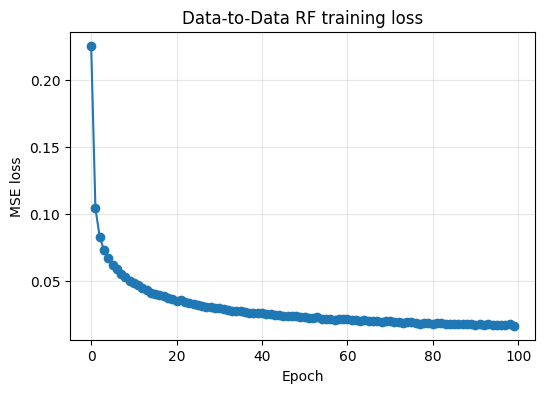

In [18]:
plt.figure(figsize=(6, 4))
plt.plot(loss_history, marker="o")
plt.title("Data-to-Data RF training loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.grid(alpha=0.3)
plt.show()

### 2.1 Evaluation on held-out test pairs

After training/loading, evaluate in `eval` mode on the test pair loader.

This gives a cleaner estimate of generalization than training loss alone.

In [19]:
@torch.no_grad()
def evaluate_on_test_loader(model_rf, loader, device, max_batches=None):
    model_rf.model.eval()

    total_loss = 0.0
    total_batches = 0

    for i, (x_a, x_b, cond, _, _) in enumerate(loader):
        if max_batches is not None and i >= max_batches:
            break

        x_a = x_a.to(device)
        x_b = x_b.to(device)
        cond = cond.to(device)

        b = x_a.size(0)
        t = torch.rand((b,), device=device)
        texp = t.view([b, *([1] * len(x_a.shape[1:]))])

        z_t = (1 - texp) * x_a + texp * x_b
        target_velocity = x_b - x_a

        pred_velocity = model_rf.model(z_t, t, cond)
        loss = F.mse_loss(pred_velocity, target_velocity)

        total_loss += loss.item()
        total_batches += 1

    return total_loss / max(1, total_batches), total_batches


# Set to None for full test set, or a small number (e.g., 20) for a quick check.
EVAL_MAX_BATCHES = None

test_loss, n_eval_batches = evaluate_on_test_loader(
    rf_d2d,
    test_loader,
    device,
    max_batches=EVAL_MAX_BATCHES,
)

print(f"Eval mode active: {not rf_d2d.model.training}")
print(f"Evaluated batches: {n_eval_batches}")
print(f"Mean test MSE loss: {test_loss:.6f}")

# If available, show last train/val entries from training cell for quick generalization check.
if "train_loss_history" in globals() and len(train_loss_history) > 0:
    print(f"Last train loss: {train_loss_history[-1]:.6f}")
if "val_loss_history" in globals() and len(val_loss_history) > 0:
    print(f"Last val loss (during training): {val_loss_history[-1]:.6f}")
if (
    "train_loss_history" in globals()
    and "val_loss_history" in globals()
    and len(train_loss_history) > 0
    and len(val_loss_history) > 0
):
    gap = val_loss_history[-1] - train_loss_history[-1]
    print(f"Generalization gap (val-train): {gap:+.6f}")

Eval mode active: True
Evaluated batches: 40
Mean test MSE loss: 0.015608
Last train loss: 0.016838
Last val loss (during training): 0.016770
Generalization gap (val-train): -0.000068


### 2.2 Export best artifacts to Google Drive

This cell exports:

- best checkpoint
- latest trajectory payload
- a sample PNG image
- an animated GIF of the trajectory

into Google Drive so artifacts survive Colab runtime resets.

In [14]:
import shutil
from datetime import datetime

try:
    import imageio.v2 as imageio
except Exception:
    import imageio

# 1) Mount Google Drive if running in Colab.
IN_COLAB = "google.colab" in sys.modules
drive_available = False

if IN_COLAB:
    try:
        from google.colab import drive

        drive.mount("/content/drive", force_remount=False)
        drive_available = True
        print("Google Drive mounted successfully.")
    except Exception as e:
        print("Google Drive mount failed. Falling back to local export.")
        print("Mount error:", repr(e))
else:
    print("Not in Colab: exporting to local fallback directory under repo assets.")

# 2) Prepare export destination.
run_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
if drive_available:
    export_root = Path("/content/drive/MyDrive/minRF_exports") / run_timestamp
else:
    export_root = repo_path / "assets" / "exports" / run_timestamp

export_root.mkdir(parents=True, exist_ok=True)
print("Export directory:", export_root)

# 3) Resolve best checkpoint path.
if "best_ckpt_path" in globals() and Path(best_ckpt_path).exists():
    ckpt_src = Path(best_ckpt_path)
elif "latest_ckpt_path" in globals() and Path(latest_ckpt_path).exists():
    ckpt_src = Path(latest_ckpt_path)
else:
    raise FileNotFoundError("No checkpoint found. Run the training cell first.")

ckpt_dst = export_root / ckpt_src.name
shutil.copy2(ckpt_src, ckpt_dst)
print("Saved checkpoint copy:", ckpt_dst)

# 4) Build trajectory payload in Notebook-3 style:
# Prefer in-memory trajectory from experiment cell, then file, then on-the-fly generation.
traj_payload = None
traj_src = None

if "flow_full" in globals() and flow_full is not None and len(flow_full) > 0:
    traj_payload = {
        "trajectory": torch.stack([t.detach().cpu() for t in flow_full], dim=0),
        "source": x_a.detach().cpu() if "x_a" in globals() else None,
        "target": x_b.detach().cpu() if "x_b" in globals() else None,
        "cond": cond.detach().cpu() if "cond" in globals() else None,
        "y_a": int(Y_A) if "Y_A" in globals() else -1,
        "y_b": int(Y_B) if "Y_B" in globals() else -1,
        "from": "in_memory_flow_full",
    }
    print("Using in-memory trajectory from experiment cell.")
else:
    traj_src_candidates = [
        run_dir / "d2d_trajectory_latest.pt" if "run_dir" in globals() else None,
        repo_path / "assets" / "d2d_runs" / "d2d_trajectory_latest.pt",
    ]
    traj_src_candidates = [p for p in traj_src_candidates if p is not None]
    traj_src = next((p for p in traj_src_candidates if p.exists()), None)

    if traj_src is not None:
        traj_payload = torch.load(traj_src, map_location="cpu")
        print("Using saved trajectory file:", traj_src)
    else:
        print("No trajectory file found. Creating a fresh trajectory now...")

        if "rf_d2d" not in globals():
            raise RuntimeError("Model wrapper rf_d2d not found. Run the training/loading cell first.")
        if "test_dataset" not in globals() or "test_label_index" not in globals() or "TRAIN_CLASS_PAIRS" not in globals():
            raise RuntimeError("Dataset metadata missing. Run dataset cells first.")

        y_a, y_b = TRAIN_CLASS_PAIRS[0]
        idx_a = random.choice(test_label_index[y_a])
        x_a_fallback, _ = test_dataset[idx_a]
        x_a_fallback = x_a_fallback.unsqueeze(0).to(device)
        cond_fallback = torch.tensor([y_a * 10 + y_b], device=device)

        if "run_flow_trajectory" in globals():
            _, flow_full_fallback = run_flow_trajectory(rf_d2d, x_a_fallback, cond_fallback, steps=50, n_vis=9)
        else:
            rf_d2d.model.eval()
            with torch.no_grad():
                flow_full_fallback = rf_d2d.sample(x_a_fallback, cond_fallback, steps=50)

        traj_payload = {
            "trajectory": torch.stack([t.detach().cpu() for t in flow_full_fallback], dim=0),
            "source": x_a_fallback.detach().cpu(),
            "cond": cond_fallback.detach().cpu(),
            "y_a": int(y_a),
            "y_b": int(y_b),
            "from": "generated_in_export_cell",
        }

# 5) Persist trajectory payload copy into export folder and standard run folder.
run_traj_path = (run_dir if "run_dir" in globals() else (repo_path / "assets" / "d2d_runs")) / "d2d_trajectory_latest.pt"
run_traj_path.parent.mkdir(parents=True, exist_ok=True)
torch.save(traj_payload, run_traj_path)
print("Updated run trajectory file:", run_traj_path)

traj_dst = export_root / "d2d_trajectory_latest.pt"
torch.save(traj_payload, traj_dst)
print("Saved trajectory copy:", traj_dst)

trajectory = traj_payload["trajectory"]  # shape: [T, B, C, H, W]

# 6) Create sample PNG from final frame.
def to_uint8_gray(img_tensor):
    x = (img_tensor * 0.5 + 0.5).clamp(0, 1)
    arr = (x.squeeze().numpy() * 255).astype("uint8")
    return arr

sample_img = to_uint8_gray(trajectory[-1, 0])
sample_png_path = export_root / "sample_final.png"
imageio.imwrite(sample_png_path, sample_img)
print("Saved sample PNG:", sample_png_path)

# 7) Create GIF from trajectory frames.
frames = [to_uint8_gray(trajectory[t, 0]) for t in range(trajectory.shape[0])]
gif_path = export_root / "trajectory.gif"
imageio.mimsave(gif_path, frames, duration=0.08, loop=0)
print("Saved GIF:", gif_path)

# 8) Save lightweight metadata for reproducibility.
meta = {
    "checkpoint_source": str(ckpt_src),
    "trajectory_source": str(traj_src) if traj_src is not None else "in_memory_or_generated",
    "num_frames": int(trajectory.shape[0]),
    "y_a": int(traj_payload.get("y_a", -1)),
    "y_b": int(traj_payload.get("y_b", -1)),
    "export_to_drive": bool(drive_available),
    "export_root": str(export_root),
    "trajectory_origin": traj_payload.get("from", "unknown"),
}
meta_path = export_root / "export_meta.pt"
torch.save(meta, meta_path)
print("Saved export metadata:", meta_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully.
Export directory: /content/drive/MyDrive/minRF_exports/20260804_004710
Saved checkpoint copy: /content/drive/MyDrive/minRF_exports/20260804_004710/d2d_checkpoint_best.pt
No trajectory file found. Creating a fresh trajectory now...
Updated run trajectory file: /content/minRF_interpolation/assets/d2d_runs/d2d_trajectory_latest.pt
Saved trajectory copy: /content/drive/MyDrive/minRF_exports/20260804_004710/d2d_trajectory_latest.pt
Saved sample PNG: /content/drive/MyDrive/minRF_exports/20260804_004710/sample_final.png
Saved GIF: /content/drive/MyDrive/minRF_exports/20260804_004710/trajectory.gif
Saved export metadata: /content/drive/MyDrive/minRF_exports/20260804_004710/export_meta.pt


## 3. Experiments (analog to Notebook 03)

We compare two interpolation strategies:

1. **Linear interpolation baseline**
2. **Learned flow trajectory** from the data-to-data model

for selected source-target pairs.

In [15]:
@torch.no_grad()
def linear_interpolation(x_a, x_b, steps=9):
    ts = torch.linspace(0, 1, steps, device=x_a.device)
    out = []
    for t in ts:
        out.append((1 - t) * x_a + t * x_b)
    return out


@torch.no_grad()
def run_flow_trajectory(model_rf, x_a, cond, steps=50, n_vis=9):
    traj = model_rf.sample(x_a, cond, steps=steps)
    idxs = torch.linspace(0, len(traj) - 1, n_vis).long().tolist()
    return [traj[i] for i in idxs], traj


def plot_two_rows(images_top, images_bottom, title_top, title_bottom, main_title):
    n = len(images_top)
    fig, axes = plt.subplots(2, n, figsize=(1.8 * n, 4.2))

    for i in range(n):
        axes[0, i].imshow(denorm(images_top[i]).squeeze(), cmap="gray")
        axes[0, i].axis("off")

        axes[1, i].imshow(denorm(images_bottom[i]).squeeze(), cmap="gray")
        axes[1, i].axis("off")

    axes[0, 0].set_ylabel(title_top, fontsize=10)
    axes[1, 0].set_ylabel(title_bottom, fontsize=10)
    plt.suptitle(main_title)
    plt.tight_layout()
    plt.show()


def pair_to_cond(y_a, y_b):
    return y_a * 10 + y_b

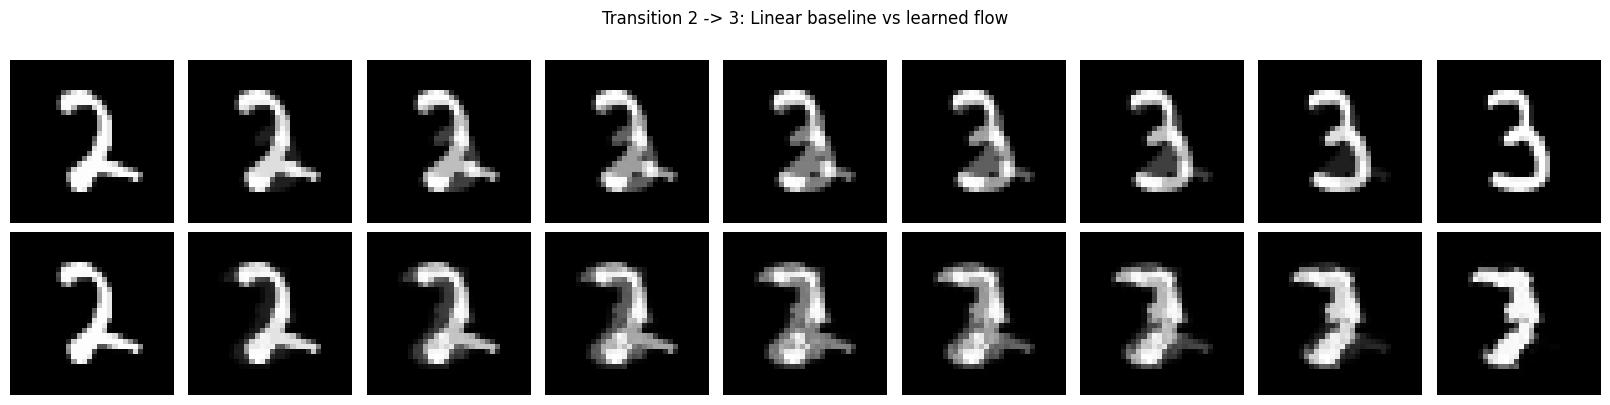

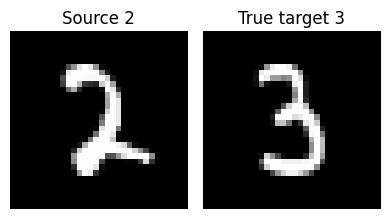

Saved latest trajectory to: /content/minRF_interpolation/assets/d2d_runs/d2d_trajectory_latest.pt


In [16]:
# Pick one concrete mapping to inspect closely.
Y_A, Y_B = 2, 3
assert (Y_A, Y_B) in TRAIN_CLASS_PAIRS

# Get one source/target pair from test set.
idx_a = random.choice(test_label_index[Y_A])
idx_b = random.choice(test_label_index[Y_B])

x_a, _ = test_dataset[idx_a]
x_b, _ = test_dataset[idx_b]

x_a = x_a.unsqueeze(0).to(device)
x_b = x_b.unsqueeze(0).to(device)
cond = torch.tensor([pair_to_cond(Y_A, Y_B)], device=device)

lin_steps = linear_interpolation(x_a, x_b, steps=9)
flow_vis, flow_full = run_flow_trajectory(rf_d2d, x_a, cond, steps=50, n_vis=9)

plot_two_rows(
    images_top=[img[0].detach().cpu() for img in lin_steps],
    images_bottom=[img[0].detach().cpu() for img in flow_vis],
    title_top="Linear",
    title_bottom="Flow",
    main_title=f"Transition {Y_A} -> {Y_B}: Linear baseline vs learned flow",
)

# Also show source and true target side-by-side for reference.
fig, ax = plt.subplots(1, 2, figsize=(4, 2.2))
ax[0].imshow(denorm(x_a[0].detach().cpu()).squeeze(), cmap="gray")
ax[0].set_title(f"Source {Y_A}")
ax[0].axis("off")
ax[1].imshow(denorm(x_b[0].detach().cpu()).squeeze(), cmap="gray")
ax[1].set_title(f"True target {Y_B}")
ax[1].axis("off")
plt.tight_layout()
plt.show()

# Persist the latest trajectory so it can be inspected later without re-running everything.
traj_path = run_dir / "d2d_trajectory_latest.pt"
traj_payload = {
    "trajectory": torch.stack([t.detach().cpu() for t in flow_full], dim=0),
    "source": x_a.detach().cpu(),
    "target": x_b.detach().cpu(),
    "cond": cond.detach().cpu(),
    "y_a": int(Y_A),
    "y_b": int(Y_B),
}
torch.save(traj_payload, traj_path)
print("Saved latest trajectory to:", traj_path)

In [17]:
@torch.no_grad()
def endpoint_metrics(x_a, x_b, flow_full):
    # Compare endpoint errors for linear and learned path.
    flow_end = flow_full[-1]

    lin_end = x_b

    flow_l1_to_target = (flow_end - x_b).abs().mean().item()
    linear_l1_to_target = (lin_end - x_b).abs().mean().item()

    flow_l1_to_source = (flow_end - x_a).abs().mean().item()
    linear_l1_to_source = (lin_end - x_a).abs().mean().item()

    return {
        "flow_l1_to_target": flow_l1_to_target,
        "linear_l1_to_target": linear_l1_to_target,
        "flow_l1_to_source": flow_l1_to_source,
        "linear_l1_to_source": linear_l1_to_source,
    }


m = endpoint_metrics(x_a, x_b, flow_full)
print("Endpoint metrics for selected example")
print("  Flow   L1(end, target):", f"{m['flow_l1_to_target']:.4f}")
print("  Linear L1(end, target):", f"{m['linear_l1_to_target']:.4f}")
print("  Flow   L1(end, source):", f"{m['flow_l1_to_source']:.4f}")
print("  Linear L1(end, source):", f"{m['linear_l1_to_source']:.4f}")

Endpoint metrics for selected example
  Flow   L1(end, target): 0.1963
  Linear L1(end, target): 0.0000
  Flow   L1(end, source): 0.1442
  Linear L1(end, source): 0.1753


## 3.1 Semantic transition evaluation with a classifier

The core research question is distribution-level interpolation on **unpaired samples**.

To evaluate this beyond pixel loss, we train/load a small MNIST classifier and measure:

- target-class confidence along the trajectory
- predicted class at the endpoint
- smoothness of semantic transition over time

This helps answer whether trajectories move samples toward the **target distribution**, not whether they reconstruct one exact target instance.

In [20]:
class MNISTEvalClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.net(x)


@torch.no_grad()
def classifier_probs(model, x_batch):
    model.eval()
    logits = model(x_batch)
    return torch.softmax(logits, dim=1)


# Train once and reuse from checkpoint.
clf_path = run_dir / "mnist_eval_classifier.pt"
eval_clf = MNISTEvalClassifier().to(device)

if clf_path.exists():
    eval_clf.load_state_dict(torch.load(clf_path, map_location=device))
    print("Loaded classifier checkpoint:", clf_path)
else:
    print("Training classifier for semantic evaluation...")
    clf_epochs = 3
    clf_max_batches = 300

    clf_train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, drop_last=True)
    clf_opt = torch.optim.Adam(eval_clf.parameters(), lr=1e-3)
    clf_loss = nn.CrossEntropyLoss()

    for ep in range(clf_epochs):
        eval_clf.train()
        running = 0.0
        steps = 0

        for i, (x, y) in enumerate(clf_train_loader):
            if i >= clf_max_batches:
                break

            x = x.to(device)
            y = y.to(device)

            clf_opt.zero_grad()
            logits = eval_clf(x)
            loss = clf_loss(logits, y)
            loss.backward()
            clf_opt.step()

            running += loss.item()
            steps += 1

        print(f"Classifier epoch {ep + 1}/{clf_epochs} | loss: {running / max(1, steps):.4f}")

    torch.save(eval_clf.state_dict(), clf_path)
    print("Saved classifier checkpoint:", clf_path)


@torch.no_grad()
def trajectory_semantic_curve(eval_model, trajectory_list, target_label):
    probs = []
    pred = []

    for z in trajectory_list:
        p = classifier_probs(eval_model, z.to(device))[0].detach().cpu()
        probs.append(float(p[target_label]))
        pred.append(int(torch.argmax(p).item()))

    return probs, pred

Training classifier for semantic evaluation...
Classifier epoch 1/3 | loss: 0.2826
Classifier epoch 2/3 | loss: 0.0624
Classifier epoch 3/3 | loss: 0.0463
Saved classifier checkpoint: /content/minRF_interpolation/assets/d2d_runs/mnist_eval_classifier.pt


Step | Flow pred | Flow p(target) | Linear pred | Linear p(target)
   0 |         2 |         0.0000 |           2 |           0.0000
   5 |         2 |         0.0000 |           2 |           0.0000
  10 |         2 |         0.0000 |           2 |           0.0000
  15 |         2 |         0.0008 |           2 |           0.0005
  20 |         2 |         0.0204 |           2 |           0.0134
  25 |         2 |         0.2496 |           2 |           0.3931
  30 |         3 |         0.5196 |           3 |           0.9493
  35 |         3 |         0.7450 |           3 |           0.9951
  40 |         3 |         0.8703 |           3 |           0.9986
  45 |         3 |         0.9365 |           3 |           0.9994
  50 |         3 |         0.9580 |           3 |           0.9997


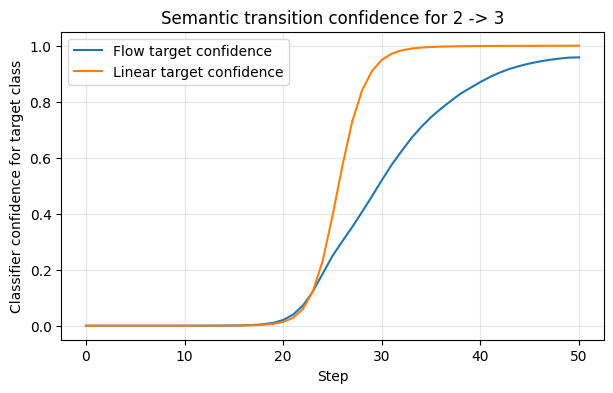

In [21]:
# Semantic curve on the current example (Y_A -> Y_B).
steps_for_eval = 51
linear_full = linear_interpolation(x_a, x_b, steps=steps_for_eval)
_, flow_full_eval = run_flow_trajectory(rf_d2d, x_a, cond, steps=50, n_vis=9)

flow_target_conf, flow_pred = trajectory_semantic_curve(eval_clf, flow_full_eval, Y_B)
lin_target_conf, lin_pred = trajectory_semantic_curve(eval_clf, linear_full, Y_B)

print("Step | Flow pred | Flow p(target) | Linear pred | Linear p(target)")
for s in range(0, min(len(flow_target_conf), len(lin_target_conf)), 5):
    print(
        f"{s:>4} |"
        f" {flow_pred[s]:>9} | {flow_target_conf[s]:>14.4f} |"
        f" {lin_pred[s]:>11} | {lin_target_conf[s]:>16.4f}"
    )

plt.figure(figsize=(7, 4))
plt.plot(flow_target_conf, label="Flow target confidence")
plt.plot(lin_target_conf, label="Linear target confidence")
plt.xlabel("Step")
plt.ylabel("Classifier confidence for target class")
plt.title(f"Semantic transition confidence for {Y_A} -> {Y_B}")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Classifier-based trajectory evaluation

- **Step**  
  - Position along the generated trajectory
  - Step 0 corresponds to the source sample, while the final step corresponds to the generated endpoint

- **Flow pred**  
  - Predicted class label of the intermediate sample generated by the Rectified Flow
  - Indicates which class the classifier assigns to the current flow state

- **Flow p(target)**  
  - Classifier confidence for the target class on the Flow-generated intermediate sample
  - Measures how strongly the trajectory moves towards the desired target distribution

- **Linear pred**  
  - Predicted class label of the corresponding linearly interpolated sample
  - Used as a baseline comparison

- **Linear p(target)**  
  - Classifier confidence for the target class on the linearly interpolated sample
  - Shows how quickly the simple pixel-space interpolation moves towards the target class

### 3.2 Random-pair transition evaluation

This experiment evaluates many random unpaired samples for one class mapping (default: 2 -> 3):

- endpoint target-class accuracy
- endpoint target confidence
- confidence smoothness along the path
- manifold confidence (mean max softmax along the path)

This directly addresses distribution-level transport quality.

In [22]:
@torch.no_grad()
def evaluate_mapping_distribution(
    eval_model,
    flow_model,
    source_label,
    target_label,
    n_pairs=100,
    steps=50,
):
    flow_endpoint_correct = 0
    linear_endpoint_correct = 0

    flow_target_conf_final = []
    linear_target_conf_final = []

    flow_monotonicity = []
    linear_monotonicity = []

    flow_manifold_conf = []
    linear_manifold_conf = []

    for _ in range(n_pairs):
        idx_a = random.choice(test_label_index[source_label])
        idx_b = random.choice(test_label_index[target_label])

        x_a_local, _ = test_dataset[idx_a]
        x_b_local, _ = test_dataset[idx_b]

        x_a_local = x_a_local.unsqueeze(0).to(device)
        x_b_local = x_b_local.unsqueeze(0).to(device)
        cond_local = torch.tensor([pair_to_cond(source_label, target_label)], device=device)

        linear_traj = linear_interpolation(x_a_local, x_b_local, steps=steps + 1)
        _, flow_traj = run_flow_trajectory(flow_model, x_a_local, cond_local, steps=steps, n_vis=9)

        flow_probs = []
        linear_probs = []

        for zf, zl in zip(flow_traj, linear_traj):
            p_f = classifier_probs(eval_model, zf.to(device))[0].detach().cpu()
            p_l = classifier_probs(eval_model, zl.to(device))[0].detach().cpu()
            flow_probs.append(p_f)
            linear_probs.append(p_l)

        flow_probs = torch.stack(flow_probs, dim=0)
        linear_probs = torch.stack(linear_probs, dim=0)

        flow_final_pred = int(torch.argmax(flow_probs[-1]).item())
        linear_final_pred = int(torch.argmax(linear_probs[-1]).item())

        flow_endpoint_correct += int(flow_final_pred == target_label)
        linear_endpoint_correct += int(linear_final_pred == target_label)

        flow_target_conf_final.append(float(flow_probs[-1, target_label]))
        linear_target_conf_final.append(float(linear_probs[-1, target_label]))

        # Fraction of steps where target confidence increases.
        flow_diff = flow_probs[1:, target_label] - flow_probs[:-1, target_label]
        linear_diff = linear_probs[1:, target_label] - linear_probs[:-1, target_label]
        flow_monotonicity.append(float((flow_diff > 0).float().mean().item()))
        linear_monotonicity.append(float((linear_diff > 0).float().mean().item()))

        # Average classifier certainty across the path as manifold proxy.
        flow_manifold_conf.append(float(flow_probs.max(dim=1).values.mean().item()))
        linear_manifold_conf.append(float(linear_probs.max(dim=1).values.mean().item()))

    out = {
        "source_label": source_label,
        "target_label": target_label,
        "n_pairs": n_pairs,
        "flow_endpoint_acc": flow_endpoint_correct / n_pairs,
        "linear_endpoint_acc": linear_endpoint_correct / n_pairs,
        "flow_final_target_conf": float(torch.tensor(flow_target_conf_final).mean().item()),
        "linear_final_target_conf": float(torch.tensor(linear_target_conf_final).mean().item()),
        "flow_monotonicity": float(torch.tensor(flow_monotonicity).mean().item()),
        "linear_monotonicity": float(torch.tensor(linear_monotonicity).mean().item()),
        "flow_manifold_conf": float(torch.tensor(flow_manifold_conf).mean().item()),
        "linear_manifold_conf": float(torch.tensor(linear_manifold_conf).mean().item()),
    }
    return out


mapping_result = evaluate_mapping_distribution(
    eval_model=eval_clf,
    flow_model=rf_d2d,
    source_label=2,
    target_label=3,
    n_pairs=100,
    steps=50,
)

print("Random-pair semantic evaluation (2 -> 3)")
for k, v in mapping_result.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

Random-pair semantic evaluation (2 -> 3)
  source_label: 2
  target_label: 3
  n_pairs: 100
  flow_endpoint_acc: 0.6400
  linear_endpoint_acc: 0.9900
  flow_final_target_conf: 0.6387
  linear_final_target_conf: 0.9714
  flow_monotonicity: 0.8670
  linear_monotonicity: 0.9790
  flow_manifold_conf: 0.8745
  linear_manifold_conf: 0.9221


### Evaluation metrics random pair transition

- **Endpoint accuracy**
  - Measures how often the final generated sample is classified as the target class
  - Indicates whether the flow reaches the desired semantic distribution

- **Final target confidence**
  - Measures the classifier confidence for the target class at the final step
  - Shows how strongly the generated endpoint resembles the target class

- **Monotonicity**
  - Measures how consistently the target-class probability increases along the trajectory
  - Indicates whether the transition evolves smoothly towards the target

- **Manifold confidence**
  - Measures the average classifier confidence for the most likely class along the trajectory
  - Serves as a proxy for whether intermediate states remain meaningful data samples

### 3.3 Optional: direct GIF comparison (Linear vs Flow)

This produces one side-by-side GIF for the same source sample:

- left: linear interpolation
- right: learned flow trajectory

Use this for qualitative path-geometry inspection.

In [ ]:
import numpy as np

try:
    import imageio.v2 as imageio
except Exception:
    import imageio


def to_uint8_digit(img_tensor):
    x = (img_tensor * 0.5 + 0.5).clamp(0, 1)
    return (x.squeeze().detach().cpu().numpy() * 255).astype(np.uint8)


@torch.no_grad()
def save_linear_vs_flow_gif(x_a_local, x_b_local, cond_local, out_path, steps=50, duration=0.08):
    linear_traj = linear_interpolation(x_a_local, x_b_local, steps=steps + 1)
    _, flow_traj = run_flow_trajectory(rf_d2d, x_a_local, cond_local, steps=steps, n_vis=9)

    frames = []
    for z_lin, z_flow in zip(linear_traj, flow_traj):
        img_lin = to_uint8_digit(z_lin[0])
        img_flow = to_uint8_digit(z_flow[0])
        spacer = np.full((img_lin.shape[0], 4), 255, dtype=np.uint8)
        frame = np.concatenate([img_lin, spacer, img_flow], axis=1)
        frames.append(frame)

    imageio.mimsave(out_path, frames, duration=duration, loop=0)
    return out_path


gif_compare_dir = export_root if "export_root" in globals() else run_dir
gif_compare_dir.mkdir(parents=True, exist_ok=True)
gif_compare_path = gif_compare_dir / f"linear_vs_flow_{Y_A}_to_{Y_B}.gif"

save_linear_vs_flow_gif(
    x_a_local=x_a,
    x_b_local=x_b,
    cond_local=cond,
    out_path=gif_compare_path,
    steps=50,
    duration=0.08,
)

print("Saved side-by-side comparison GIF:", gif_compare_path)

## 5. Diagnostics performed

The next code cells evaluate two blocks:

- **5.1 Single trajectory:** NN manifold proxy for one example (2 -> 3).
- **5.2 Random-pair aggregation:** same metric across many random unpaired pairs.

The full interpretation is consolidated in the final section.

### 5.1 Single trajectory: NN manifold proxy

For one example (2 -> 3), we compute at each time step the distance to a MNIST reference bank:

$$
d(z_t, \mathcal{D}) = \min_{x \in \mathcal{D}} \|z_t - x\|_2.
$$

Built NN reference bank with shape: (5000, 1024)


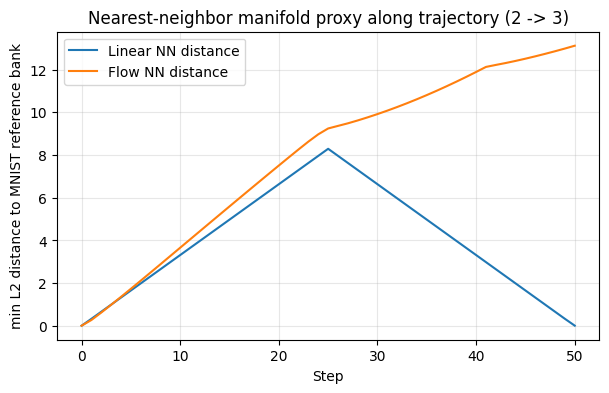

NN manifold-proxy summary
  Linear mean distance: 4.0650
  Flow   mean distance: 7.9152
  Linear max  distance: 8.2919
  Flow   max  distance: 13.1173


In [23]:
@torch.no_grad()
def build_reference_bank(dataset, max_items=5000, seed=42):
    """Create a flattened reference bank from MNIST samples for nearest-neighbor distance."""
    n = len(dataset)
    max_items = min(max_items, n)

    g = torch.Generator().manual_seed(seed)
    idx = torch.randperm(n, generator=g)[:max_items]

    xs = []
    for i in idx.tolist():
        x_i, _ = dataset[i]
        xs.append(x_i.view(-1))

    bank = torch.stack(xs, dim=0).float()
    return bank


@torch.no_grad()
def min_l2_distance_to_bank(z, bank_flat):
    """Compute min L2 distance from one image tensor z=[1,C,H,W] to a flat bank [N,D]."""
    z_flat = z.view(1, -1).detach().cpu().float()
    d = torch.cdist(z_flat, bank_flat, p=2)
    return float(d.min().item())


@torch.no_grad()
def trajectory_nn_curve(trajectory, bank_flat):
    dists = []
    for z_t in trajectory:
        dists.append(min_l2_distance_to_bank(z_t, bank_flat))
    return dists


# Build (or reuse) a manifold-proxy reference bank from real MNIST samples.
if "nn_bank_flat" not in globals():
    nn_bank_flat = build_reference_bank(test_dataset, max_items=5000, seed=SEED)
    print("Built NN reference bank with shape:", tuple(nn_bank_flat.shape))
else:
    print("Reusing existing NN reference bank with shape:", tuple(nn_bank_flat.shape))

# Use the current example (x_a, x_b, cond).
steps_nn = 50
linear_traj_nn = linear_interpolation(x_a, x_b, steps=steps_nn + 1)
_, flow_traj_nn = run_flow_trajectory(rf_d2d, x_a, cond, steps=steps_nn, n_vis=9)

linear_nn = trajectory_nn_curve(linear_traj_nn, nn_bank_flat)
flow_nn = trajectory_nn_curve(flow_traj_nn, nn_bank_flat)

t = list(range(len(flow_nn)))
plt.figure(figsize=(7, 4))
plt.plot(t, linear_nn, label="Linear NN distance")
plt.plot(t, flow_nn, label="Flow NN distance")
plt.xlabel("Step")
plt.ylabel("min L2 distance to MNIST reference bank")
plt.title(f"Nearest-neighbor manifold proxy along trajectory ({Y_A} -> {Y_B})")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print("NN manifold-proxy summary")
print(f"  Linear mean distance: {float(torch.tensor(linear_nn).mean()):.4f}")
print(f"  Flow   mean distance: {float(torch.tensor(flow_nn).mean()):.4f}")
print(f"  Linear max  distance: {float(torch.tensor(linear_nn).max()):.4f}")
print(f"  Flow   max  distance: {float(torch.tensor(flow_nn).max()):.4f}")

### 5.2 Random-pair aggregation

The same NN manifold proxy metric is aggregated over many random unpaired pairs to compare behavior across trajectories more robustly.

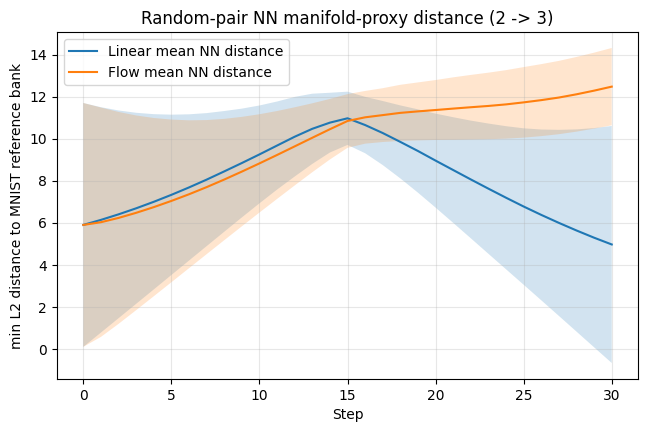

Random-pair NN manifold-proxy summary (2 -> 3)
  n_pairs: 40
  steps: 30
  Linear mean distance: 8.0444
  Flow   mean distance: 9.7955
  Linear endpoint mean distance: 4.9719
  Flow   endpoint mean distance: 12.4812
  Flow step-advantage fraction: 0.4484


In [24]:
@torch.no_grad()
def evaluate_mapping_nn_distribution(
    flow_model,
    source_label,
    target_label,
    n_pairs=40,
    steps=30,
    bank_flat=None,
):
    """Aggregate NN manifold-proxy distances over random unpaired pairs."""
    if bank_flat is None:
        if "nn_bank_flat" not in globals():
            raise RuntimeError("nn_bank_flat not found. Run Section 4.2 first.")
        bank_flat = nn_bank_flat

    linear_curves = []
    flow_curves = []

    for _ in range(n_pairs):
        idx_a = random.choice(test_label_index[source_label])
        idx_b = random.choice(test_label_index[target_label])

        x_a_local, _ = test_dataset[idx_a]
        x_b_local, _ = test_dataset[idx_b]

        x_a_local = x_a_local.unsqueeze(0).to(device)
        x_b_local = x_b_local.unsqueeze(0).to(device)
        cond_local = torch.tensor([pair_to_cond(source_label, target_label)], device=device)

        linear_traj = linear_interpolation(x_a_local, x_b_local, steps=steps + 1)
        _, flow_traj = run_flow_trajectory(flow_model, x_a_local, cond_local, steps=steps, n_vis=9)

        linear_curve = torch.tensor(trajectory_nn_curve(linear_traj, bank_flat), dtype=torch.float32)
        flow_curve = torch.tensor(trajectory_nn_curve(flow_traj, bank_flat), dtype=torch.float32)

        linear_curves.append(linear_curve)
        flow_curves.append(flow_curve)

    linear_mat = torch.stack(linear_curves, dim=0)  # [P, T]
    flow_mat = torch.stack(flow_curves, dim=0)      # [P, T]

    # Per-pair advantage: fraction of steps where flow is closer to manifold proxy.
    per_pair_step_adv = (flow_mat < linear_mat).float().mean(dim=1)

    result = {
        "source_label": int(source_label),
        "target_label": int(target_label),
        "n_pairs": int(n_pairs),
        "steps": int(steps),
        "linear_mean_curve": linear_mat.mean(dim=0),
        "flow_mean_curve": flow_mat.mean(dim=0),
        "linear_std_curve": linear_mat.std(dim=0),
        "flow_std_curve": flow_mat.std(dim=0),
        "linear_mean_dist": float(linear_mat.mean().item()),
        "flow_mean_dist": float(flow_mat.mean().item()),
        "linear_endpoint_mean_dist": float(linear_mat[:, -1].mean().item()),
        "flow_endpoint_mean_dist": float(flow_mat[:, -1].mean().item()),
        "flow_step_advantage_mean": float(per_pair_step_adv.mean().item()),
    }
    return result


nn_result = evaluate_mapping_nn_distribution(
    flow_model=rf_d2d,
    source_label=2,
    target_label=3,
    n_pairs=40,
    steps=30,
)

xs = torch.arange(nn_result["steps"] + 1)
lin_mu = nn_result["linear_mean_curve"]
flow_mu = nn_result["flow_mean_curve"]
lin_sd = nn_result["linear_std_curve"]
flow_sd = nn_result["flow_std_curve"]

plt.figure(figsize=(7.5, 4.5))
plt.plot(xs, lin_mu, label="Linear mean NN distance")
plt.fill_between(xs.numpy(), (lin_mu - lin_sd).numpy(), (lin_mu + lin_sd).numpy(), alpha=0.2)
plt.plot(xs, flow_mu, label="Flow mean NN distance")
plt.fill_between(xs.numpy(), (flow_mu - flow_sd).numpy(), (flow_mu + flow_sd).numpy(), alpha=0.2)
plt.xlabel("Step")
plt.ylabel("min L2 distance to MNIST reference bank")
plt.title("Random-pair NN manifold-proxy distance (2 -> 3)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print("Random-pair NN manifold-proxy summary (2 -> 3)")
print(f"  n_pairs: {nn_result['n_pairs']}")
print(f"  steps: {nn_result['steps']}")
print(f"  Linear mean distance: {nn_result['linear_mean_dist']:.4f}")
print(f"  Flow   mean distance: {nn_result['flow_mean_dist']:.4f}")
print(f"  Linear endpoint mean distance: {nn_result['linear_endpoint_mean_dist']:.4f}")
print(f"  Flow   endpoint mean distance: {nn_result['flow_endpoint_mean_dist']:.4f}")
print(f"  Flow step-advantage fraction: {nn_result['flow_step_advantage_mean']:.4f}")

## Setup Review

- **Data:** MNIST, normalized to [-1, 1], input size 32x32.
- **Task:** Unpaired, class-conditioned data-to-data mapping (including 2 -> 3).
- **Model:** Rectified-Flow/DiT backbone with conditioned velocity prediction.
- **Training:** Flow matching on paths \(z_t=(1-t)x_A+t x_B\) with target \(u_t=x_B-x_A\).
- **Comparison:** Learned flow vs. linear interpolation.
- **Evaluation:**
  - semantic trajectory proxy (classifier-based),
  - NN manifold proxy along trajectories (single example + random-pair aggregation).

## Final summary: What was done, results, meaning

### What was done?

- Trained a data-to-data Flow Matching model on MNIST for unpaired, class-conditioned transitions (e.g., 2 -> 3).
- Compared learned flow trajectories against linear interpolation.
- Evaluated:
  - training/generalization behavior,
  - semantic transition behavior (classifier-based proxy),
  - proximity to the empirical data distribution (nearest-neighbor proxy).

### Main results

- **Training:** Stable transport learning objective (train/val/test loss around 0.016).
- **Semantics:** Flow shows structured transitions toward the target class.
- **Endpoint metrics:** Flow does not outperform linear interpolation.
- **Manifold proxy:** In the current setup, linear interpolation stays closer to the empirical MNIST distribution -> as to be expected

### Interpretation

- The model learns a non-trivial conditional transport field between two data distributions.
- Current evidence does not show superiority of learned flow over linear interpolation.
- Main open question: how to define and measure interpolation quality more meaningfully.

### Overview table

| Area | Metric | Flow | Linear | Short interpretation |
|---|---:|---:|---:|---|
| Optimization | Final train loss | 0.016838 | - | stable learning |
| Optimization | Final val loss | 0.016770 | - | no visible overfitting |
| Optimization | Test loss | 0.015608 | - | good generalization |
| Semantics (100 pairs, 2->3) | Endpoint accuracy | 0.6400 | 0.9900 | linear clearly better at endpoint |
| Semantics (100 pairs, 2->3) | Final target confidence | 0.6387 | 0.9714 | linear more confident at endpoint |
| Semantics (100 pairs, 2->3) | Monotonicity | 0.8670 | 0.9790 | linear more consistent |
| NN proxy (single, 2->3) | Mean distance | 7.9152 | 4.0650 | linear closer to reference bank |
| NN proxy (random, 40 pairs, 2->3) | Mean distance | 9.7955 | 8.0444 | linear closer on average |
| NN proxy (random, 40 pairs, 2->3) | Endpoint mean distance | 12.4812 | 4.9719 | clear endpoint disadvantage for flow |
| NN proxy (random, 40 pairs, 2->3) | Flow step advantage | 0.4484 | - | flow closer in < 50% of steps |